# The OpenSense example datasets

The OpenSense community publishes small, curated subsets of the open
opportunistic-sensing datasets at
[OpenSenseAction/opensense_example_data](https://github.com/OpenSenseAction/opensense_example_data):
one folder per source dataset, one NetCDF file per sensor type, and several
durations of the same data (`_1d`, `_1w`, `_8d`, ...). They are what the
`poligrain`, `pypwsqc` and `mergeplg` examples run on.

FieldSense reads them with `core.opensense.example_data`: `load()` downloads a
file on first use into `dataset/open_datasets/_example_subsets/` (git-ignored),
checks its size, and returns a dict keyed by sensor type.

| folder | region | sensors | notebook |
|---|---|---|---|
| `OpenMRG` | Gothenburg, Sweden, July 2015 | CML, radar, municipal + SMHI gauges | `01_openmrg.ipynb` |
| `OpenRainER` | Emilia-Romagna, Italy, August 2022 | CML, radar, gauges | `02_openrainer.ipynb` |
| `OpenMesh` | New York City, January 2024 | CML, PWS, ASOS | `03_openmesh.ipynb` |
| `AMS_PWS` | Amsterdam, 2016-2018 | PWS, radar-derived reference | `04_ams_pws.ipynb` |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import poligrain as plg

from core import viz_style as vs
from core.opensense import example_data, plots

vs.use_style()
C1, C2, C3 = (vs.SERIES[k] for k in vs.SERIES_ORDER)

## Every file

This cell downloads everything (about 57 MB) and tabulates what each file
holds. Sizes are the compressed files on disk; the OpenMRG 8-day CML file is
27 MB on disk and 1.2 GB in memory, which is why the per-dataset notebooks load
it one day at a time.

In [2]:
import xarray as xr

rows = []
for spec in example_data.DATASETS.values():
    for subset in spec.subsets:
        for sensor, path in example_data.download(spec.key, subset, verbose=False).items():
            with xr.open_dataset(path) as ds:           # header only, nothing loaded
                t = ds.time.values
                rows.append({"dataset": spec.name, "subset": subset, "sensor": sensor,
                             "file": path.name, "MB": round(path.stat().st_size / 1e6, 2),
                             "start": pd.Timestamp(t[0]).floor("min"),
                             "end": pd.Timestamp(t[-1]).floor("min"),
                             "dims": ", ".join(f"{k}={v}" for k, v in ds.sizes.items())})
table = pd.DataFrame(rows)
print(f"{len(table)} files, {table.MB.sum():.1f} MB")
table

20 files, 59.9 MB


,dataset,subset,sensor,file,MB,start,end,dims
0,OpenMRG,8d,cml,openmrg_cml_8d.nc,26.87,2015-07-22 00:00:00,2015-07-29 23:59:00,"sublink_id=2, cml_id=364, time=69120"
1,OpenMRG,8d,radar,openmrg_rad_8d.nc,1.25,2015-07-22 00:00:00,2015-07-29 23:55:00,"time=2304, x=37, y=48"
2,OpenMRG,8d,gauge_municipal,openmrg_municp_gauge_8d.nc,0.13,2015-07-22 00:00:00,2015-07-29 23:59:00,"id=10, time=11520"
3,OpenMRG,8d,gauge_smhi,openmrg_smhi_gauge_8d.nc,0.02,2015-07-22 00:00:00,2015-07-29 23:45:00,"id=1, time=768"
4,OpenMRG,5min_2h,cml,openmrg_cml_5min_2h.nc,0.15,2015-07-25 12:30:00,2015-07-25 15:00:00,"cml_id=359, time=31"
5,OpenMRG,5min_2h,radar,openmrg_rad_5min_2h.nc,0.48,2015-07-25 12:30:00,2015-07-25 15:00:00,"time=31, x=37, y=48"
6,OpenMRG,5min_2h,gauge_municipal,openmrg_municp_gauge_5min_2h.nc,0.01,2015-07-25 12:30:00,2015-07-25 15:00:00,"time=31, station_id=10"
7,OpenMRG,5min_2h,gauge_smhi,openmrg_smhi_gauge_5min_2h.nc,0.01,2015-07-25 12:30:00,2015-07-25 15:00:00,"station_id=1, time=31"
8,OpenRainER,8d,cml,openrainer_cml_8d.nc,0.83,2022-08-14 00:00:00,2022-08-21 23:59:00,"time=11412, sublink_id=2, cml_id=151"
9,OpenRainER,8d,radar,openrainer_radar_8d.nc,15.98,2022-08-14 00:00:00,2022-08-21 23:45:00,"time=768, y=290, x=373"


## One call per dataset

`load()` returns `{sensor: xarray.Dataset}`. With `normalize=True` (the
default) it also evens out the differences between the files: link length in
km and frequency in GHz whatever unit was stored, one polarization spelling,
projected `x`/`y` for every sensor, and a rain rate `R` in mm/h next to the
per-step `rainfall_amount` of gauges and PWS. The per-dataset notebooks show
where each of those matters.

In [3]:
data = example_data.load("openmrg", "5min_2h", verbose=False)
for sensor, ds in data.items():
    print(f"{sensor:16s} {dict(ds.sizes)}  vars={list(ds.data_vars)}")

cml              {'cml_id': 359, 'time': 31}  vars=['R']
radar            {'time': 31, 'y': 48, 'x': 37}  vars=['crs', 'R']
gauge_municipal  {'time': 31, 'id': 10}  vars=['rainfall_amount', 'R']
gauge_smhi       {'id': 1, 'time': 31}  vars=['rainfall_amount', 'R']


## The four networks

Links as lines, point sensors as dots, all in longitude/latitude.

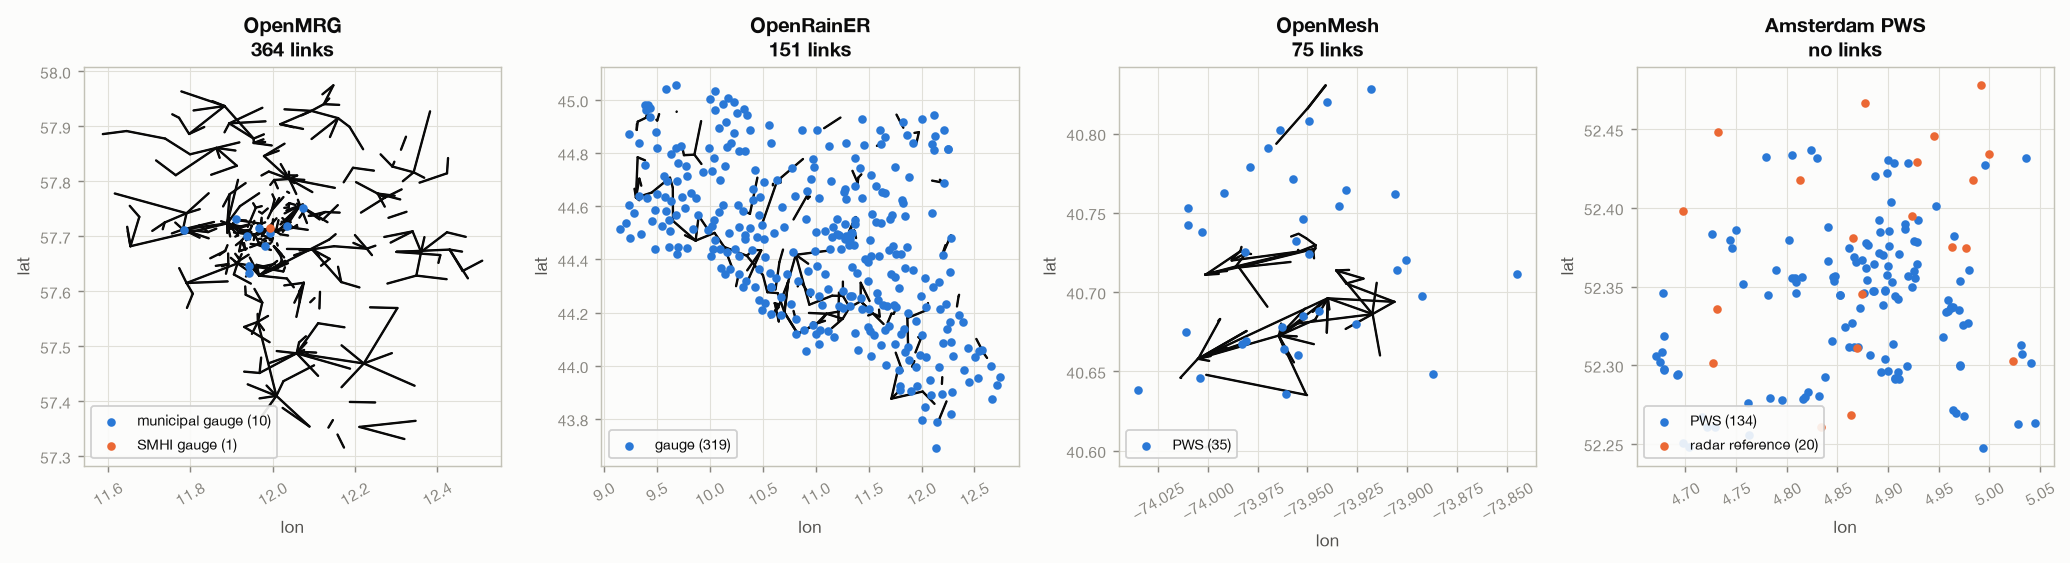

In [4]:
nets = {
    "OpenMRG": example_data.load("openmrg", "8d", verbose=False,
                                 time=slice("2015-07-25", "2015-07-25")),
    "OpenRainER": example_data.load("openrainer", "8d", verbose=False),
    "OpenMesh": example_data.load("openmesh", "1d", verbose=False),
    "Amsterdam PWS": example_data.load("ams_pws", "full_period", verbose=False),
}
point_names = {"gauge_municipal": "municipal gauge", "gauge_smhi": "SMHI gauge",
               "gauge": "gauge", "pws": "PWS", "asos": "ASOS"}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, (name, d) in zip(axes, nets.items()):
    if "cml" in d:
        plg.plot_map.plot_lines(plots._links(d["cml"]), use_lon_lat=True, ax=ax,
                                line_color=vs.INK_PRIMARY, line_width=0.8)
    for (sensor, pts), c in zip([(k, v) for k, v in d.items() if k in point_names],
                                (C1, C2, C3)):
        label = "radar reference" if name == "Amsterdam PWS" and sensor == "gauge" \
            else point_names[sensor]
        ax.scatter(pts.lon, pts.lat, s=14, color=c, zorder=5,
                   label=f"{label} ({pts.sizes['id']})")
    links = f"{d['cml'].sizes['cml_id']} links" if "cml" in d else "no links"
    ax.set(title=f"{name}\n{links}", xlabel="lon", ylabel="lat")
    ax.tick_params(axis="x", labelrotation=30)
    ax.legend(loc="lower left", fontsize=8, frameon=True, framealpha=0.9)
fig.tight_layout()

## Next

| | |
|---|---|
| `01_openmrg.ipynb` - `04_ams_pws.ipynb` | each dataset in depth: structure, the traps in its files, first plots |
| `projects/opensense_pipeline/` | retrieval and merging on these subsets (`run_pipeline.py --source example`) |
| `core/opensense/fetch.py` | the full Zenodo records, when a few days is not enough |